# Hotel Booking Cancellation Prediction & Decision System

## 1. Business Problem

Hotel booking cancellations can lead to unused rooms, revenue loss, and inefficient inventory planning. Predicting whether a booking is likely to be cancelled can help hotels take preventive actions such as confirmation follow-ups, deposit requirements, or targeted retention strategies.

The objective of this project is to develop a machine learning system that predicts the probability of a hotel booking being cancelled using information available at the time of booking.

The project follows an end-to-end machine learning workflow:

* Data cleaning and preprocessing
* Exploratory data analysis
* Feature engineering
* Classification model development
* Model evaluation
* Cancellation probability prediction
* Risk-based business recommendations

The final system will classify bookings into cancellation-risk levels and provide an actionable recommendation based on the predicted probability.



In [ ]:
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost joblib


In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
import sys

print(sys.executable)
print(os.getcwd())

C:\Users\KARTIK SRIBVASTAVA\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe
c:\Users\KARTIK SRIBVASTAVA\OneDrive\Desktop\studeies\ml\practise project\hotel booking anal


In [4]:
data = pd.read_csv("hotel_bookings.csv")

In [5]:
data.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [7]:
data.shape

(119390, 32)

In [8]:
data.isnull().sum().sort_values(ascending = False)

company                           112593
agent                              16340
country                              488
children                               4
arrival_date_month                     0
arrival_date_week_number               0
hotel                                  0
is_canceled                            0
stays_in_weekend_nights                0
arrival_date_day_of_month              0
adults                                 0
stays_in_week_nights                   0
babies                                 0
meal                                   0
lead_time                              0
arrival_date_year                      0
distribution_channel                   0
market_segment                         0
previous_bookings_not_canceled         0
is_repeated_guest                      0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
previous_cancellations                 0
deposit_type    

In [9]:
data['company'].value_counts(dropna = False)

company
NaN      112593
40.0        927
223.0       784
67.0        267
45.0        250
          ...  
479.0         1
489.0         1
229.0         1
481.0         1
497.0         1
Name: count, Length: 353, dtype: int64

In [10]:
data["company"].isna().value_counts()

company
True     112593
False      6797
Name: count, dtype: int64

In [11]:
pd.crosstab(data["customer_type"],data["company"].isna(),normalize="index")*100

company,False,True
customer_type,,
Contract,0.122669,99.877331
Group,8.492201,91.507799
Transient,4.633256,95.366744
Transient-Party,10.312848,89.687152


In [12]:
data['agent'].value_counts(dropna = False)

agent
9.0      31961
NaN      16340
240.0    13922
1.0       7191
14.0      3640
         ...  
444.0        1
408.0        1
388.0        1
453.0        1
480.0        1
Name: count, Length: 334, dtype: int64

In [13]:
data["agent"].isna().value_counts()

agent
False    103050
True      16340
Name: count, dtype: int64

In [14]:
pd.crosstab(data['distribution_channel'],data['agent'].isna(),normalize=True)*100

agent,False,True
distribution_channel,,
Corporate,0.949828,4.642767
Direct,5.879889,6.386632
GDS,0.159980,0.001675
TA/TO,79.322389,2.652651
Undefined,0.001675,0.002513


In [15]:
pd.crosstab(
    data["market_segment"],
    data["agent"].isna(),
    normalize="index"
) * 100

agent,False,True
market_segment,,
Aviation,10.548523,89.451477
Complementary,13.862719,86.137281
Corporate,13.238905,86.761095
Direct,52.348088,47.651912
Groups,79.062137,20.937863
Offline TA/TO,98.393823,1.606177
Online TA,99.383820,0.616180
Undefined,0.000000,100.000000


In [16]:
data['has_agent'] = data['agent'].notna().astype(int)

In [17]:
data["country"].value_counts(dropna=False).head(20)

country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
ITA     3766
IRL     3375
BEL     2342
BRA     2224
NLD     2104
USA     2097
CHE     1730
CN      1279
AUT     1263
SWE     1024
CHN      999
POL      919
ISR      669
RUS      632
NOR      607
Name: count, dtype: int64

In [18]:
data["country"].isna().value_counts()

country
False    118902
True        488
Name: count, dtype: int64

In [19]:
data['country'] = data['country'].fillna('unknown')

In [20]:
data['country'].isna().value_counts()

country
False    119390
Name: count, dtype: int64

In [21]:
data["children"].value_counts(dropna=False)

children
0.0     110796
1.0       4861
2.0       3652
3.0         76
NaN          4
10.0         1
Name: count, dtype: int64

In [22]:
data[data["children"].isna()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,has_agent
40600,City Hotel,1,2,2015,August,32,3,1,0,2,...,NaN,NaN,0,Transient-Party,12.0,0,1,Canceled,2015-08-01,0
40667,City Hotel,1,1,2015,August,32,5,0,2,2,...,14.0,NaN,0,Transient-Party,12.0,0,1,Canceled,2015-08-04,1
40679,City Hotel,1,1,2015,August,32,5,0,2,3,...,NaN,NaN,0,Transient-Party,18.0,0,2,Canceled,2015-08-04,0
41160,City Hotel,1,8,2015,August,33,13,2,5,2,...,9.0,NaN,0,Transient-Party,76.5,0,1,Canceled,2015-08-09,1


In [23]:
data = data.dropna(subset = ['children'])

In [24]:
data.duplicated().value_counts()

False    87392
True     31994
Name: count, dtype: int64

In [25]:
data.duplicated().value_counts()

False    87392
True     31994
Name: count, dtype: int64

In [26]:
data.shape

(119386, 33)

In [27]:
data.duplicated().sum()

np.int64(31994)

In [28]:
data['reservation_status'].unique()

<StringArray>
['Check-Out', 'Canceled', 'No-Show']
Length: 3, dtype: str

In [29]:
data["reservation_status"].value_counts()

reservation_status
Check-Out    75166
Canceled     43013
No-Show       1207
Name: count, dtype: int64

In [30]:
data.groupby("reservation_status")["is_canceled"].value_counts(normalize = True)

reservation_status  is_canceled
Canceled            1              1.0
Check-Out           0              1.0
No-Show             1              1.0
Name: proportion, dtype: float64

In [31]:
leakage_cols = [
    "reservation_status",
    "reservation_status_date"
]

In [32]:
data["is_canceled"].value_counts(normalize=True) * 100

is_canceled
0    62.960481
1    37.039519
Name: proportion, dtype: float64

In [33]:
data.info()

<class 'pandas.DataFrame'>
Index: 119386 entries, 0 to 119389
Data columns (total 33 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119386 non-null  str    
 1   is_canceled                     119386 non-null  int64  
 2   lead_time                       119386 non-null  int64  
 3   arrival_date_year               119386 non-null  int64  
 4   arrival_date_month              119386 non-null  str    
 5   arrival_date_week_number        119386 non-null  int64  
 6   arrival_date_day_of_month       119386 non-null  int64  
 7   stays_in_weekend_nights         119386 non-null  int64  
 8   stays_in_week_nights            119386 non-null  int64  
 9   adults                          119386 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119386 non-null  int64  
 12  meal                            

In [34]:
pd.crosstab(data['hotel'],data['is_canceled'],normalize = 'index')*100

is_canceled,0,1
hotel,,
City Hotel,58.275975,41.724025
Resort Hotel,72.236645,27.763355


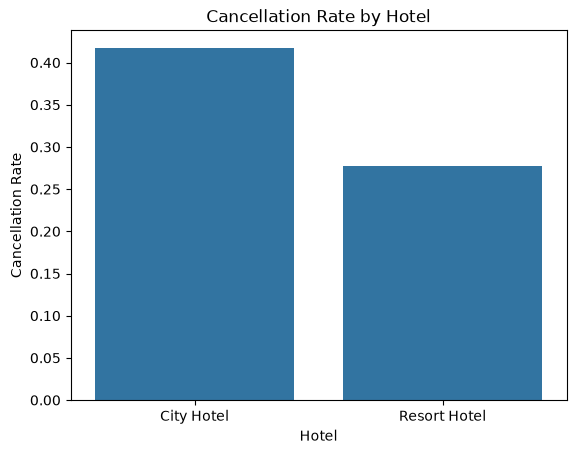

In [35]:


cancellation_by_hotel = (
    data.groupby("hotel")["is_canceled"]
    .mean()
    .sort_values(ascending=False)
)

sns.barplot(data = cancellation_by_hotel.reset_index(), x = "hotel", y = "is_canceled")

plt.ylabel("Cancellation Rate")
plt.xlabel("Hotel")
plt.title("Cancellation Rate by Hotel")
plt.xticks(rotation=0)
plt.show()

In [36]:
data.groupby("is_canceled")["lead_time"].describe()

,count,mean,std,min,25%,50%,75%,max
is_canceled,,,,,,,,
0,75166.0,79.984687,91.109888,0.0,9.0,45.0,124.0,737.0
1,44220.0,144.861646,118.622518,0.0,48.0,113.0,214.0,629.0


In [37]:
bins = [0, 7, 30, 90, 180, float("inf")]
labels = [
    "0-7 days",
    "8-30 days",
    "31-90 days",
    "91-180 days",
    "181+ days"
]

data["lead_time_group"] = pd.cut(
    data["lead_time"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [38]:
lead_time_cancellation = (
    data.groupby("lead_time_group")["is_canceled"]
    .mean() * 100
)

lead_time_cancellation

lead_time_group
0-7 days        9.618599
8-30 days      27.860119
31-90 days     37.698372
91-180 days    44.710466
181+ days      57.010368
Name: is_canceled, dtype: float64

In [39]:
pd.crosstab(data['deposit_type'],data['is_canceled'],normalize = 'index')*100

is_canceled,0,1
deposit_type,,
No Deposit,71.625716,28.374284
Non Refund,0.637554,99.362446
Refundable,77.777778,22.222222


In [40]:
data.groupby('deposit_type')['is_canceled'].agg(['count','sum'])

,count,sum
deposit_type,,
No Deposit,104637,29690
Non Refund,14587,14494
Refundable,162,36


In [41]:
pd.crosstab(
    data["customer_type"],
    data["is_canceled"],
    normalize="index"
) * 100

is_canceled,0,1
customer_type,,
Contract,69.038273,30.961727
Group,89.774697,10.225303
Transient,59.253680,40.746320
Transient-Party,74.582006,25.417994


In [42]:
pd.crosstab(
    data["market_segment"],
    data["is_canceled"],
    normalize="index"
) * 100

is_canceled,0,1
market_segment,,
Aviation,78.059072,21.940928
Complementary,86.944818,13.055182
Corporate,81.265345,18.734655
Direct,84.664816,15.335184
Groups,38.937964,61.062036
Offline TA/TO,65.683967,34.316033
Online TA,63.279977,36.720023


In [43]:
data["market_segment"].value_counts()

market_segment
Online TA        56476
Offline TA/TO    24219
Groups           19811
Direct           12605
Corporate         5295
Complementary      743
Aviation           237
Name: count, dtype: int64

In [44]:
data.groupby("previous_cancellations")["is_canceled"].agg(
    ["count", "sum","mean"]
).sort_index()

,count,sum,mean
previous_cancellations,,,
0,112902,38278,0.339037
1,6051,5714,0.944307
2,116,38,0.327586
3,65,20,0.307692
4,31,7,0.225806
5,19,2,0.105263
6,22,7,0.318182
11,35,10,0.285714
13,12,11,0.916667


In [45]:
pd.crosstab(
    data["is_repeated_guest"],
    data["is_canceled"],
)

is_canceled,0,1
is_repeated_guest,,
0,71908,43668
1,3258,552


In [46]:
result = data.groupby("total_of_special_requests")["is_canceled"].agg(
    count="count",
    canceled="sum",
    cancellation_rate="mean"
)
result['cancellation_rate'] *=100
result

,count,canceled,cancellation_rate
total_of_special_requests,,,
0,70318,33556,47.720356
1,33223,7315,22.017879
2,12968,2865,22.092844
3,2497,446,17.861434
4,340,36,10.588235
5,40,2,5.000000


In [47]:
result = data.groupby("previous_cancellations")["is_canceled"].agg(
    total="count",
    canceled="sum"
)

result["not_canceled"] = result["total"] - result["canceled"]
result["cancellation_rate"] = result["canceled"] / result["total"] * 100

result

,total,canceled,not_canceled,cancellation_rate
previous_cancellations,,,,
0,112902,38278,74624,33.903740
1,6051,5714,337,94.430673
2,116,38,78,32.758621
3,65,20,45,30.769231
4,31,7,24,22.580645
5,19,2,17,10.526316
6,22,7,15,31.818182
11,35,10,25,28.571429
13,12,11,1,91.666667


In [48]:

data = data.drop(columns=leakage_cols)

data.shape

(119386, 32)

In [49]:
data.dtypes

hotel                                  str
is_canceled                          int64
lead_time                            int64
arrival_date_year                    int64
arrival_date_month                     str
arrival_date_week_number             int64
arrival_date_day_of_month            int64
stays_in_weekend_nights              int64
stays_in_week_nights                 int64
adults                               int64
children                           float64
babies                               int64
meal                                   str
country                                str
market_segment                         str
distribution_channel                   str
is_repeated_guest                    int64
previous_cancellations               int64
previous_bookings_not_canceled       int64
reserved_room_type                     str
assigned_room_type                     str
booking_changes                      int64
deposit_type                           str
agent      

In [50]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119386.0,0.370395,0.482913,0.00,0.00,0.00,1.0,1.0
lead_time,119386.0,104.014801,106.863286,0.00,18.00,69.00,160.0,737.0
arrival_date_year,119386.0,2016.156593,0.707456,2015.00,2016.00,2016.00,2017.0,2017.0
arrival_date_week_number,119386.0,27.165003,13.605334,1.00,16.00,28.00,38.0,53.0
arrival_date_day_of_month,119386.0,15.798553,8.780783,1.00,8.00,16.00,23.0,31.0
stays_in_weekend_nights,119386.0,0.927605,0.998618,0.00,0.00,1.00,2.0,19.0
stays_in_week_nights,119386.0,2.500310,1.908289,0.00,1.00,2.00,3.0,50.0
adults,119386.0,1.856390,0.579261,0.00,2.00,2.00,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.00,0.0,10.0
babies,119386.0,0.007949,0.097438,0.00,0.00,0.00,0.0,10.0


In [51]:
# Feature engineering

data["total_nights"] = (
    data["stays_in_weekend_nights"] +
    data["stays_in_week_nights"]
)

data["total_guests"] = (
    data["adults"] +
    data["children"].fillna(0) +
    data["babies"]
)

data["total_previous_bookings"] = (
    data["previous_cancellations"] +
    data["previous_bookings_not_canceled"]
)

data["has_previous_booking"] = (
    data["total_previous_bookings"] > 0
).astype(int)

data["has_special_requests"] = (
    data["total_of_special_requests"] > 0
).astype(int)

data["is_room_changed"] = (
    data["reserved_room_type"] != data["assigned_room_type"]
).astype(int)

data.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,required_car_parking_spaces,total_of_special_requests,has_agent,lead_time_group,total_nights,total_guests,total_previous_bookings,has_previous_booking,has_special_requests,is_room_changed
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0,0,0,181+ days,0,2.0,0,0,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0,0,0,181+ days,0,2.0,0,0,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,0,0,0-7 days,1,1.0,0,0,0,1
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,0,1,8-30 days,1,1.0,0,0,0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,1,1,8-30 days,2,2.0,0,0,1,0


In [52]:
target = "is_canceled"

In [53]:
drop_cols = [
    "is_canceled",
    "lead_time_group",
    "agent",
    "company"
]

X = data.drop(columns=drop_cols)
y = data["is_canceled"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (119386, 34)
Target: (119386,)


In [54]:
X.head()

,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,adr,required_car_parking_spaces,total_of_special_requests,has_agent,total_nights,total_guests,total_previous_bookings,has_previous_booking,has_special_requests,is_room_changed
0,Resort Hotel,342,2015,July,27,1,0,0,2,0.0,...,0.0,0,0,0,0,2.0,0,0,0,0
1,Resort Hotel,737,2015,July,27,1,0,0,2,0.0,...,0.0,0,0,0,0,2.0,0,0,0,0
2,Resort Hotel,7,2015,July,27,1,0,1,1,0.0,...,75.0,0,0,0,1,1.0,0,0,0,1
3,Resort Hotel,13,2015,July,27,1,0,1,1,0.0,...,75.0,0,0,1,1,1.0,0,0,0,0
4,Resort Hotel,14,2015,July,27,1,0,2,2,0.0,...,98.0,0,1,1,2,2.0,0,0,1,0


In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [56]:
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']

Numerical features:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'has_agent', 'total_nights', 'total_guests', 'total_previous_bookings', 'has_previous_booking', 'has_special_requests', 'is_room_changed']


In [57]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

In [58]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)
from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        ))
    ]
)
from xgboost import XGBClassifier

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            random_state=42,
            n_jobs=-1,
            eval_metric="logloss"
        ))
    ]
)


In [59]:
logistic_pipeline.fit(X_train, y_train)
xgb_pipeline.fit(X_train, y_train)
random_forest_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](34,)","['hotel','lead_time','arrival_date_year',...,'has_previous_booking', 'has_special_requests','is_room_changed']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,34
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By speci

In [60]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }
results = {}

results["Logistic Regression"] = evaluate_model(
    logistic_pipeline, X_test, y_test
)

results["Random Forest"] = evaluate_model(
    random_forest_pipeline, X_test, y_test
)
results["XGBoost"] = evaluate_model(
    xgb_pipeline,
    X_test,
    y_test
)

results_df = pd.DataFrame(results).T
results_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.822933,0.810800,0.680801,0.740135,0.901416
Random Forest,0.889857,0.858942,0.840683,0.849714,0.956815
XGBoost,0.868624,0.848030,0.786183,0.815936,0.943961


In [61]:
rf_model = random_forest_pipeline.named_steps["model"]

feature_names = (
    random_forest_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df.head(20)

,Feature,Importance
0,num__lead_time,0.100396
14,num__adr,0.064070
171,cat__country_PRT,0.061982
247,cat__deposit_type_No Deposit,0.047685
3,num__arrival_date_day_of_month,0.046397
2,num__arrival_date_week_number,0.042686
248,cat__deposit_type_Non Refund,0.041325
16,num__total_of_special_requests,0.036486
18,num__total_nights,0.030734
23,num__is_room_changed,0.028855


In [62]:
def cancellation_risk(probability):
    if probability >= 0.70:
        return "High Risk"
    elif probability >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"


def booking_recommendation(probability):
    if probability >= 0.70:
        return "Require confirmation/deposit or proactive follow-up"
    elif probability >= 0.40:
        return "Send confirmation reminder"
    else:
        return "Normal booking handling"

In [63]:
def predict_booking_risk(booking):
    probability = random_forest_pipeline.predict_proba(booking)[0, 1]

    risk = cancellation_risk(probability)
    recommendation = booking_recommendation(probability)

    return {
        "Cancellation Probability": round(probability, 3),
        "Risk Level": risk,
        "Recommendation": recommendation
    }

In [64]:
sample_booking = X_test.iloc[[0]]

prediction = predict_booking_risk(sample_booking)

prediction

{'Cancellation Probability': np.float64(0.005),
 'Risk Level': 'Low Risk',
 'Recommendation': 'Normal booking handling'}

In [65]:
import joblib

joblib.dump(
    random_forest_pipeline,
    "hotel_cancellation_model.pkl"
)

['hotel_cancellation_model.pkl']

In [66]:
loaded_model = joblib.load(
    "hotel_cancellation_model.pkl"
)

In [68]:
joblib.dump(
    random_forest_pipeline,
    "hotel_cancellation_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [69]:
import os

print(os.getcwd())
print(os.path.exists("hotel_cancellation_model.pkl"))

c:\Users\KARTIK SRIBVASTAVA\OneDrive\Desktop\studeies\ml\practise project\hotel booking anal
True


In [70]:
loaded_model = joblib.load(
    "hotel_cancellation_model.pkl"
)

probability = loaded_model.predict_proba(X_test.iloc[[0]])[0, 1]

print("Cancellation Probability:", float(probability))

Cancellation Probability: 0.005
